In [1]:
import os
import glob
import cv2
import numpy as np
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from google.colab import drive
import random


# Dataset base
dataset_dir = "/content/drive/MyDrive/building_damage_segments"
categories = ['major-damage', 'minor-damage', 'unknown']
target_aug_count = 387  # Match the count of the 'unknown' category

# Augmentation pipeline
augmentation = A.Compose([
    A.Resize(128, 128),
    A.Rotate(limit=15),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Affine(shear=10, p=0.5),
    ToTensorV2()
])

def process_and_balance():
    for category in categories:
        folder = os.path.join(dataset_dir, category)
        all_files = glob.glob(os.path.join(folder, "*.png"))

        # Augmented output folders
        aug_img_folder = os.path.join(folder, "augmented_images")
        aug_mask_folder = os.path.join(folder, "augmented_masks")
        os.makedirs(aug_img_folder, exist_ok=True)
        os.makedirs(aug_mask_folder, exist_ok=True)

        # Check current augmented files
        current_aug = [f for f in os.listdir(aug_img_folder) if f.endswith(".png")]
        current_count = len(current_aug)

        print(f"\n📂 Category: {category}")
        print(f"🟦 Already augmented: {current_count}")

        if current_count >= target_aug_count:
            print("✅ Already balanced. Skipping.")
            continue

        # Match images and masks from original set
        masks = {os.path.basename(f).replace('_mask', ''): f for f in all_files if '_mask' in f}
        images = [f for f in all_files if '_mask' not in f]

        needed = target_aug_count - current_count
        print(f"🛠️  Augmenting {needed} more samples to reach {target_aug_count}")

        for i in tqdm(range(needed), desc=f"Augmenting {category}"):
            img_path = random.choice(images)
            img_name = os.path.basename(img_path)
            mask_path = masks.get(img_name)

            if mask_path is None:
                continue

            image = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if image is None or mask is None:
                continue

            augmented = augmentation(image=image, mask=mask)
            aug_img = augmented['image'].numpy().transpose(1, 2, 0)
            aug_mask = augmented['mask'].numpy()

            aug_img = (aug_img * 255).astype(np.uint8) if aug_img.max() <= 1.0 else aug_img
            aug_mask = aug_mask.astype(np.uint8)

            # Create unique name
            idx = current_count + i
            aug_img_name = f"aug_{category.replace('-', '')}_{idx:04}.png"
            aug_mask_name = f"aug_{category.replace('-', '')}_{idx:04}_mask.png"

            cv2.imwrite(os.path.join(aug_img_folder, aug_img_name), aug_img)
            cv2.imwrite(os.path.join(aug_mask_folder, aug_mask_name), aug_mask)

# Run it
process_and_balance()


📂 Category: major-damage
🟦 Already augmented: 387
✅ Already balanced. Skipping.

📂 Category: minor-damage
🟦 Already augmented: 387
✅ Already balanced. Skipping.

📂 Category: unknown
🟦 Already augmented: 774
✅ Already balanced. Skipping.


In [2]:
import os

image_dir = "/content/drive/MyDrive/building_damage_segments/major-damage"
files = os.listdir(image_dir)
print("Files found:", files)

Files found: ['hurricane-harvey_00000000_post_disaster_ba1e12dc-fec9-45ad-91c8-730bf1976669_major-damage_mask.png', 'hurricane-harvey_00000000_post_disaster_d9c58116-b8fa-43d4-a1b1-04b11bac7580_major-damage.png', 'hurricane-harvey_00000000_post_disaster_e451d953-9182-4788-afa1-00c4398038d5_major-damage_mask.png', 'hurricane-harvey_00000000_post_disaster_e451d953-9182-4788-afa1-00c4398038d5_major-damage.png', 'hurricane-harvey_00000000_post_disaster_5f386fbd-034c-408f-b059-f16004c81cee_major-damage_mask.png', 'hurricane-harvey_00000000_post_disaster_ba1e12dc-fec9-45ad-91c8-730bf1976669_major-damage.png', 'hurricane-harvey_00000000_post_disaster_c5549b70-5902-482a-9817-75dcc952a7be_major-damage.png', 'hurricane-harvey_00000000_post_disaster_7f52d4ea-ecbf-457d-ad84-cbf8bcf5ab56_major-damage.png', 'hurricane-harvey_00000000_post_disaster_d9c58116-b8fa-43d4-a1b1-04b11bac7580_major-damage_mask.png', 'hurricane-harvey_00000000_post_disaster_5f386fbd-034c-408f-b059-f16004c81cee_major-damage.pn

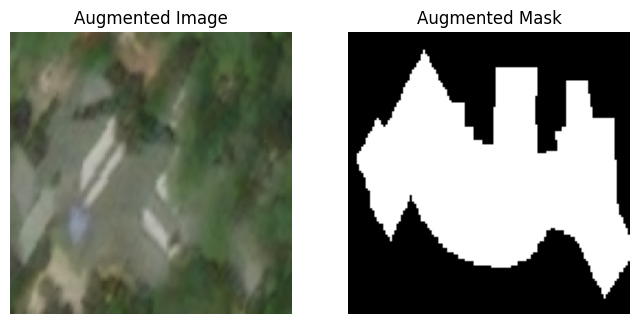

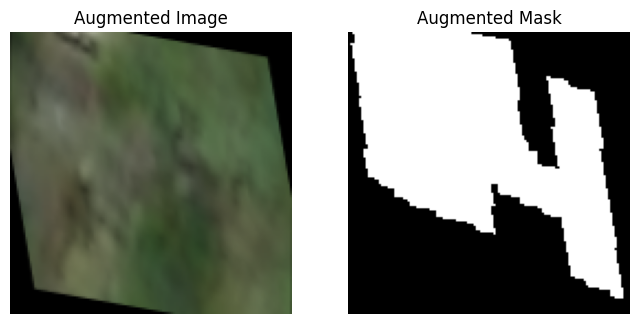

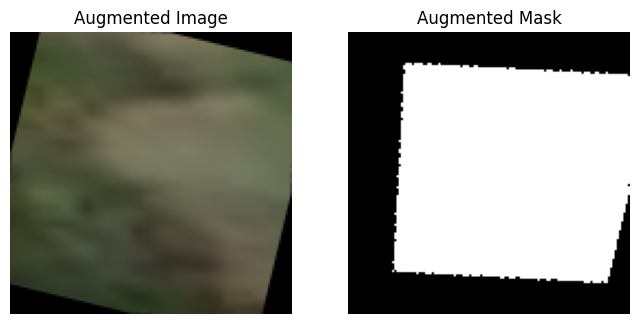

In [3]:
import matplotlib.pyplot as plt

def show_augmented_samples(category, num_samples=3):
    img_dir = f"/content/drive/MyDrive/building_damage_segments/{category}/augmented_images"
    mask_dir = f"/content/drive/MyDrive/building_damage_segments/{category}/augmented_masks"

    img_files = sorted([f for f in os.listdir(img_dir) if f.endswith('.png')])[:num_samples]

    for img_file in img_files:
        img_path = os.path.join(img_dir, img_file)
        mask_path = os.path.join(mask_dir, img_file.replace('.png', '_mask.png'))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Augmented Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='gray')
        plt.title("Augmented Mask")
        plt.axis("off")

        plt.show()

# Show a few samples from a category (e.g., 'major-damage')
show_augmented_samples('major-damage', num_samples=3)

In [4]:
import os

dataset_dir = "/content/drive/MyDrive/building_damage_segments"
categories = ['major-damage', 'minor-damage', 'unknown']

for category in categories:
    aug_img_dir = os.path.join(dataset_dir, category, "augmented_images")
    aug_mask_dir = os.path.join(dataset_dir, category, "augmented_masks")

    num_aug_images = len([f for f in os.listdir(aug_img_dir) if f.endswith(".png")])
    num_aug_masks = len([f for f in os.listdir(aug_mask_dir) if f.endswith(".png")])

    print(f"Category: {category}")
    print(f" - Augmented images: {num_aug_images}")
    print(f" - Augmented masks : {num_aug_masks}\n")

Category: major-damage
 - Augmented images: 387
 - Augmented masks : 387

Category: minor-damage
 - Augmented images: 387
 - Augmented masks : 387

Category: unknown
 - Augmented images: 774
 - Augmented masks : 774

